In [ ]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("blourdhuraju/intel-image-classification-dataset")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

Using Colab cache for faster access to the 'intel-image-classification-dataset' dataset.
Path to dataset files: /kaggle/input/intel-image-classification-dataset
Contents of base_path (/kaggle/input):
['intel-image-classification-dataset']
Contents of path (/kaggle/input/intel-image-classification-dataset):
['Intel-Image-Classification']


In [ ]:
print(f"Contents of the 'train' directory: {os.listdir(os.path.join(path, 'Intel-Image-Classification', 'train'))}")
print(f"Contents of the 'test' directory: {os.listdir(os.path.join(path, 'Intel-Image-Classification', 'test'))}")

Contents of the 'train' directory: ['mountain', 'street', 'buildings', 'sea', 'forest', 'glacier']
Contents of the 'test' directory: ['mountain', 'street', 'buildings', 'sea', 'forest', 'glacier']



--- Sample Images from Training Dataset (/kaggle/input/intel-image-classification-dataset/Intel-Image-Classification/train) ---
Found 12632 images in /kaggle/input/intel-image-classification-dataset/Intel-Image-Classification/train. Displaying 6 samples:


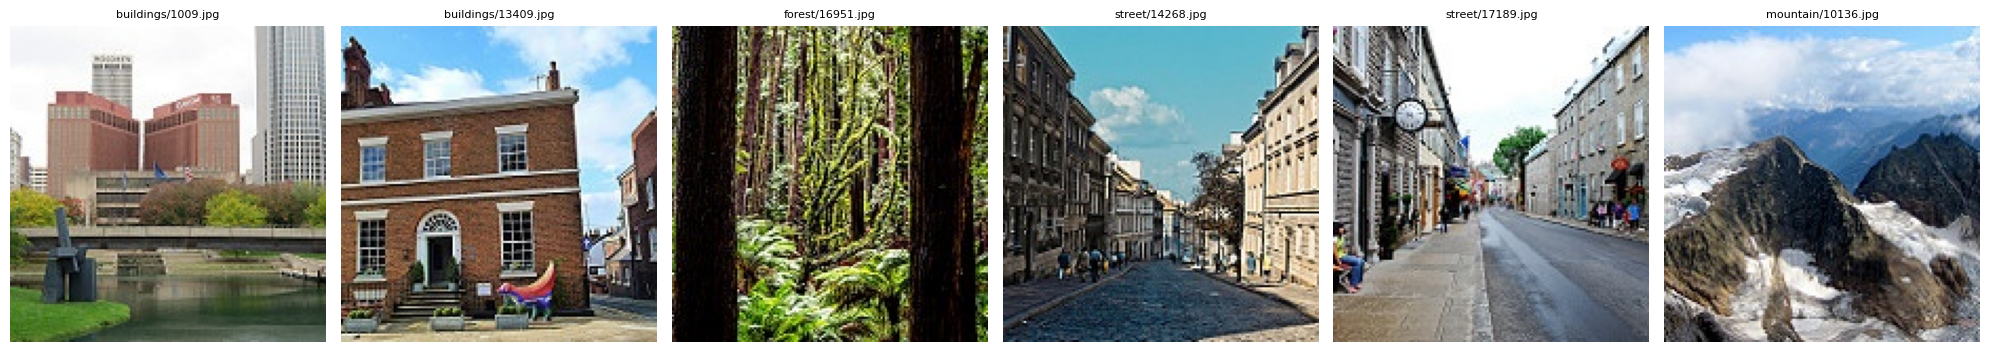


--- Sample Images from Test Dataset (/kaggle/input/intel-image-classification-dataset/Intel-Image-Classification/test) ---
Found 3000 images in /kaggle/input/intel-image-classification-dataset/Intel-Image-Classification/test. Displaying 6 samples:


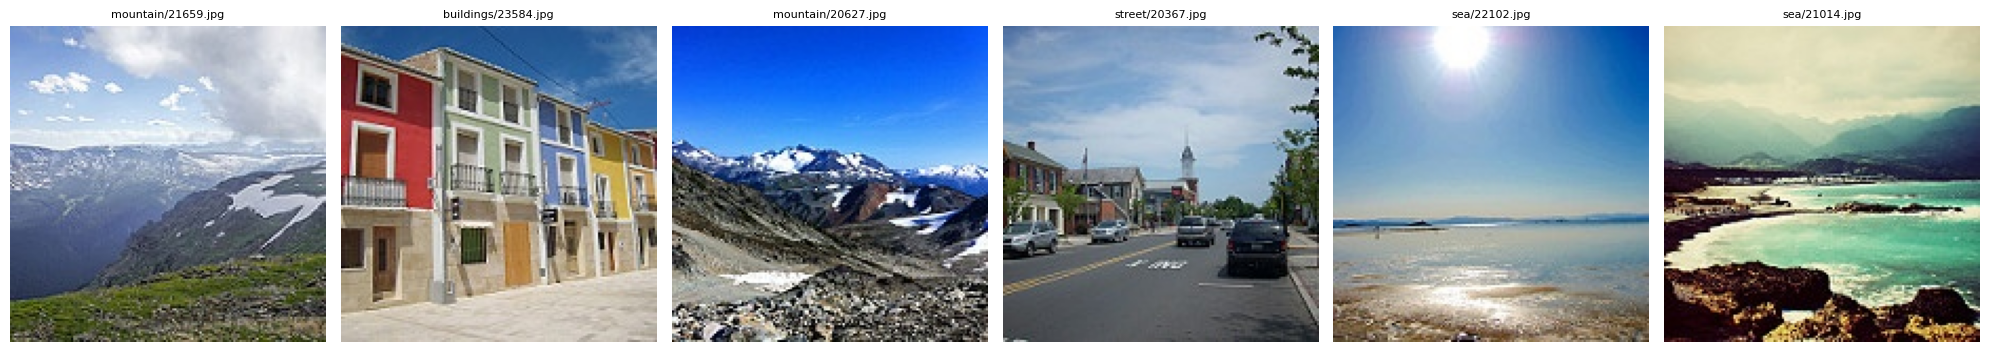

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images in {dataset_path}. Displaying {min(num_samples, len(all_image_paths))} samples:")

    # Select random samples to display
    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1:
        axes = [axes]
    elif len(samples_to_display) == 0:
        plt.close(fig)
        return

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            axes[i].set_title(os.path.basename(os.path.dirname(img_path)) + '/' + os.path.basename(img_path), fontsize=8)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Updated paths to include 'Intel-Image-Classification' subdirectory
train_path = os.path.join(path, 'Intel-Image-Classification', 'train')
print(f"\n--- Sample Images from Training Dataset ({train_path}) ---")
display_sample_images(train_path)

test_path = os.path.join(path, 'Intel-Image-Classification', 'test')
print(f"\n--- Sample Images from Test Dataset ({test_path}) ---")
display_sample_images(test_path)

In [ ]:
import tensorflow as tf

# Check if GPU is available
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
    print('GPU device not found. Running on CPU.')
else:
    print(f'Found GPU at: {device_name}')

# Display TensorFlow version
print(f'TensorFlow version: {tf.__version__}')

Found GPU at: /device:GPU:0
TensorFlow version: 2.20.0


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# Parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10

# Load datasets using image_dataset_from_directory
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# Get class names before prefetching
class_names = train_ds.class_names
num_classes = len(class_names)

# Optimize performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

# Build model
with tf.device('/GPU:0'):
    base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
    base_model.trainable = False  # Freeze base model

    model = models.Sequential([
        layers.Rescaling(1./127.5, offset=-1), # Preprocessing for MobileNetV2
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    print("Starting training...")
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS
    )

Found 12632 files belonging to 6 classes.
Found 3000 files belonging to 6 classes.
Starting training...
Epoch 1/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 65s 118ms/step - accuracy: 0.8729 - loss: 0.3537 - val_accuracy: 0.9007 - val_loss: 0.2556
Epoch 2/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 17s 44ms/step - accuracy: 0.9192 - loss: 0.2230 - val_accuracy: 0.9153 - val_loss: 0.2245
Epoch 3/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - accuracy: 0.9259 - loss: 0.2001 - val_accuracy: 0.9163 - val_loss: 0.2284
Epoch 4/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 17s 44ms/step - accuracy: 0.9328 - loss: 0.1823 - val_accuracy: 0.9160 - val_loss: 0.2314
Epoch 5/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 20s 41ms/step - accuracy: 0.9394 - loss: 0.1661 - val_accuracy: 0.9170 - val_loss: 0.2239
Epoch 6/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 19s 48ms/step - accuracy: 0.9432 - loss: 0.1566 - val_accuracy: 0.9127 - val_loss: 0.2352
Epoch 7/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 17s 42ms/step - accuracy: 0.9459 - loss: 0.1467 - val_accuracy: 0.9133 - va

In [ ]:
# Summary of training results
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print("--- Training Summary ---")
print(f"Final Training Accuracy:   {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")
print(f"Final Training Loss:       {final_train_loss:.4f}")
print(f"Final Validation Loss:     {final_val_loss:.4f}")

--- Training Summary ---
Final Training Accuracy:   0.9555
Final Validation Accuracy: 0.9147
Final Training Loss:       0.1272
Final Validation Loss:     0.2414


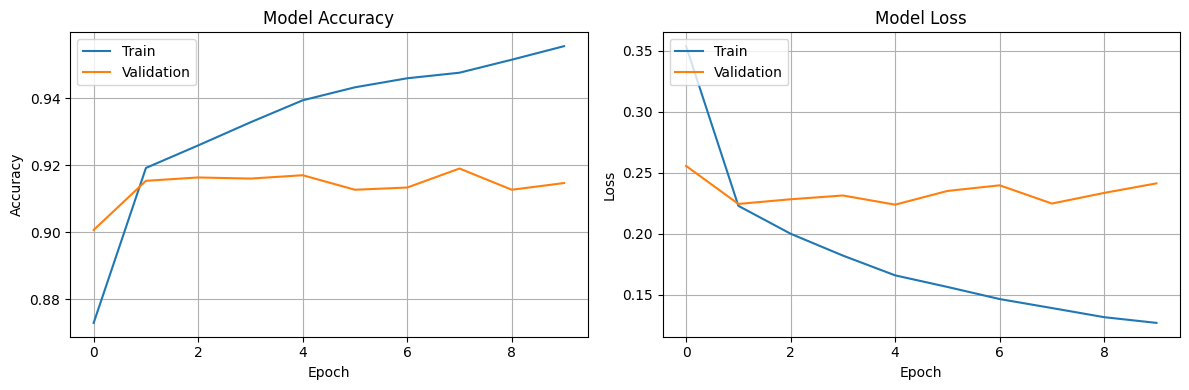

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()